In [33]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, ttest_ind
import seaborn as sns
import matplotlib.pyplot as plt

#PULIZIA DATASET
df = pd.read_csv("/Users/liadraetta/Desktop/progetti/Projects/tutorial-experiment/models_full.csv")

variables = ['population', 'gdpNominal']
df[variables] = df[variables].replace(0, np.nan)
df = df.dropna(subset=variables)  # Rimuovi righe con NaN

DISTRIBUTION PER COUNTRY POPULATIONS

In [35]:

bins = [0, 1_000_000, 10_000_000, 100_000_000, 1_000_000_000, np.inf]
labels = ['Microstates','Lower-Middle Population','Upper-Middle Population','Large States','Demographic Giants']

# Applicazione della logica con pd.cut
df['population_bin'] = pd.cut(
    df['population'], 
    bins=bins, 
    labels=labels, 
    right=False #
)

head_tail_counts = df.groupby(['population_bin', 'type'], observed=False).size().unstack(fill_value=0)

print(head_tail_counts)

type                     Head  Long-tail
population_bin                          
Microstates                13         41
Lower-Middle Population   646        913
Upper-Middle Population  4133       2868
Large States             5436       3191
Demographic Giants        511        485


In [47]:
# T-test
for var in ["population"]:
    head_values = df[df['type'] == 'Head'][var].dropna()
    tail_values = df[df['type'] == 'Long-tail'][var].dropna()
    
    t_stat, p_value = ttest_ind(head_values, tail_values)
    print(f"{var}: t={t_stat:.3f}, p={p_value:.3f}")

population: t=5.242, p=0.000


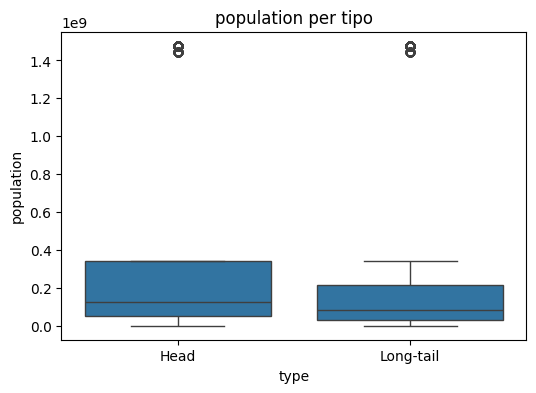

In [46]:
for var in ["population"]:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='type', y=var, data=df)
    plt.title(f'{var} per tipo')
    plt.show()

DISTRIBUTION PER GDP

In [49]:
# T-test
for var in ["gdpNominal"]:
    head_values = df[df['type'] == 'Head'][var].dropna()
    tail_values = df[df['type'] == 'Long-tail'][var].dropna()
    
    t_stat, p_value = ttest_ind(head_values, tail_values)
    print(f"{var}: t={t_stat:.3f}, p={p_value:.3f}")

gdpNominal: t=33.656, p=0.000


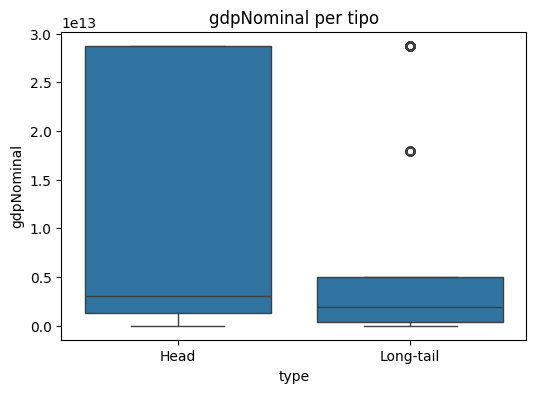

In [50]:
for var in ["gdpNominal"]:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='type', y=var, data=df)
    plt.title(f'{var} per tipo')
    plt.show()

DISTRIBUTION PER GENDER

In [28]:
gender_counts = df.groupby(['norm_gender', 'type']).size().unstack(fill_value=0)
print(gender_counts)

type         Head  Long-tail
norm_gender                 
Female       8525       6189
GenderQueer    97         32
Male         2054       1127


In [29]:
# Test chi-quadro per gender
for cat_var in ['norm_gender']:
    contingency_table = pd.crosstab(df[cat_var], df['type'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    print(f"{cat_var}: chi2={chi2:.3f}, p={p:.3f}")

norm_gender: chi2=61.362, p=0.000


type         Head  Long-tail
norm_gender                 
Female       8576       6307
GenderQueer    97         33
Male         2066       1135


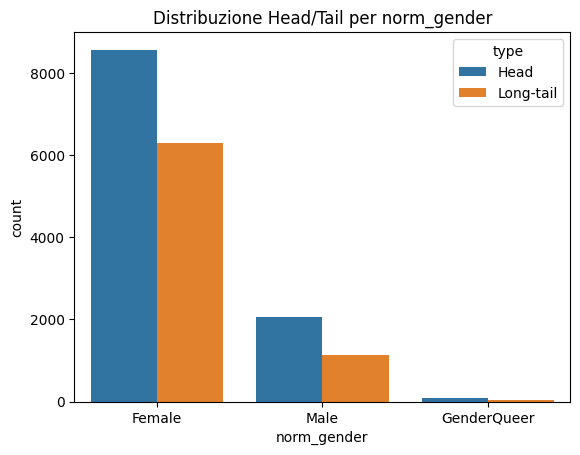

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# Tabella contingenza
contingency = pd.crosstab(df['norm_gender'], df['type'])
print(contingency)

# Grafico
sns.countplot(x='norm_gender', hue='type', data=df)
plt.title('Distribuzione Head/Tail per norm_gender')
plt.show()

DISTRIBUZION PER unm49

In [30]:
gender_counts = df.groupby(['unm49', 'type']).size().unstack(fill_value=0)
print(gender_counts)

type                       Head  Long-tail
unm49                                     
Australia and New Zealand   179        152
Caribbean                    31         51
Central America             180        186
Central Asia                  5          8
Eastern Africa               16         40
Eastern Asia               1504       1508
Eastern Europe              503        408
Middle Africa                 7         17
Northern Africa              30         16
Northern America           3486        853
Northern Europe             898        525
South America               678        947
South-eastern Asia          565        596
Southern Africa              37         60
Southern Asia               540        626
Southern Europe             690        508
Western Africa               63         63
Western Asia                358        207
Western Europe              906        577


In [31]:
for cat_var in ['unm49']:
    contingency_table = pd.crosstab(df[cat_var], df['type'])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    print(f"{cat_var}: chi2={chi2:.3f}, p={p:.3f}")

unm49: chi2=1362.125, p=0.000


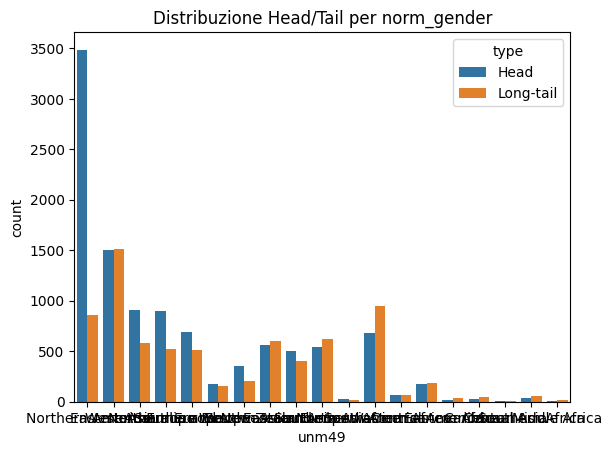

In [38]:
sns.countplot(x='unm49', hue='type', data=df)
plt.title('Distribuzione Head/Tail per norm_gender')
plt.show()

In [53]:
import plotly.express as px

df['gdpNominal'] = pd.to_numeric(df['gdpNominal'], errors='coerce')
fig = px.scatter(
    df, 
    x="claims", 
    y="gdpNominal",
    color="type",       # Colors the dots by gender
    hover_name="label_en",     # Shows the name when you hover
    hover_data=["citizenship"],# Adds extra info to the hover box
    trendline="ols",           # Adds the trendline similar to your image
    title="Relationship between Number of Claims and Nominal GDP",
    labels={
        "claims": "Number of Claims",
        "gdpNominal": "GDP Nominal (USD)"
    }
)

# 4. Improve the layout
fig.update_layout(
    template="plotly_white",
    xaxis_title="Number of Claims",
    yaxis_title="Nominal GDP"
)

# 5. Show the plot
fig.show()